# SMM Identification Test for the CMCE/ALM Parameters

## Design principle
**All target moments are computed from returns only** — no LASSO coefficients, no belief index.
The exact same estimation procedure applies to real stock return data without modification.

The only auxiliary scalar from predictor data is `sigma_x` (std of topic innovations),
which is directly observable and enters the simulator as a fixed input.

## Parameters
| Parameter | Role |
|-----------|------|
| `sigma`   | Std of idiosyncratic shock $\eta_t$ (all fundamental news; no dividend data needed) |
| `kappa`   | ALM feedback parameter $\kappa\in(0,1)$ |
| `lambda`  | LASSO penalty (sklearn alpha) |
| `s`       | Rolling-window size (integer) |

## Identification
| Moment | Formula | Primarily identifies | Why |
|--------|---------|---------------------|-----|
| $m_1$ | $\text{Var}(r_t)$ | `sigma` | Total variance ≈ fundamental var + belief-revision var |
| $m_2$ | $\text{Corr}(r_t,r_{t+1})$ | `kappa` | Stronger feedback → faster belief mean-reversion → more negative autocorr |
| $m_3$ | $\text{Kurt}(r_t)$ | `lambda` | Higher penalty → sparser beliefs → fatter return tails |
| $m_4$ | $\text{Corr}(\|r_t\|,\|r_{t+1}\|)$ | `s` | Fast-scale volatility clustering |
| $m_5$ | $\text{Corr}(\|r_t\|,\|r_{t+10}\|)$ | `s` | Slow-scale clustering; ratio $m_5/m_4 \approx e^{-9/s}$ identifies $s$ |

**Why not VarRatio(2)?**
$\text{VR}(2) = \text{Var}(r_t+r_{t+1})/2\text{Var}(r) = 1+\rho_1 = 1+m_2$ identically,
so it carries zero additional information. Using a redundant moment leaves one parameter
under-identified and destabilises the optimiser.

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats, optimize
from sklearn.linear_model import Lasso
import warnings, time
warnings.filterwarnings('ignore')
np.random.seed(0)

## 1. Simulator
Copied from `Theory/simulate_Lasso_v2.ipynb`. The LASSO coefficients are used internally
to generate returns but are **never exposed to the moment-matching step**.

In [15]:
def multivariate_CGL_offline_lasso(
    T, K, sigma_x, sigma, kappa, w,
    rolling_window_size=30, lambda_lasso=0.01
):
    """
    Simulate CMCE model under rolling-window LASSO learning.
    Returns only the log-return series r (shape T,).

    sigma : std of idiosyncratic fundamental shock (no dividend data needed)
    kappa : price-feedback parameter in (0,1)
    w     : tanh bound; set w = -log(kappa) - eps
    """
    assert rolling_window_size < T
    x    = np.random.normal(0, sigma_x, (T, K))
    beta = np.zeros((T, K))
    r    = np.zeros(T)
    r[1:rolling_window_size + 1] = np.random.normal(0, 1e-4, rolling_window_size)

    for t in range(rolling_window_size + 1, T):
        beta[t] = (
            Lasso(alpha=lambda_lasso, fit_intercept=False, random_state=42, max_iter=2000)
            .fit(x[t-rolling_window_size-1:t-1], r[t-rolling_window_size:t])
            .coef_
        )
        f_prev = float(beta[t-1] @ x[t-1])
        f_curr = float(beta[t]   @ x[t])
        r[t] = (
            np.log(1 - kappa * np.exp(w * np.tanh(f_prev / w)))
            - np.log(1 - kappa * np.exp(w * np.tanh(f_curr / w)))
            + np.random.normal(0, sigma)
        )
    return r

## 2. Moments — from returns only
This function is **identical** whether called on simulated or real data.

In [16]:
LAG_LONG = 10   # second abs-return lag; must be consistent between data and sim

def compute_moments(r):
    """
    Five moments from a 1-D log-return series.  All observable on real data.

    m1  Var(r)                              overall scale          → sigma
    m2  Corr(r_t, r_{t+1})                 lag-1 autocorr         → kappa
    m3  Kurt(r)                             Pearson kurtosis       → lambda
    m4  Corr(|r_t|, |r_{t+1}|)             lag-1 abs-autocorr     → s (fast scale)
    m5  Corr(|r_t|, |r_{t+LAG_LONG}|)      lag-L abs-autocorr     → s (slow scale)
        ratio m5/m4 ≈ exp(-(LAG_LONG-1)/s) → directly identifies s

    NOTE: VarRatio(2) = 1 + m2 exactly, so it was dropped — purely redundant.
    """
    r   = np.asarray(r, dtype=float)
    m1  = float(np.var(r, ddof=1))
    m2  = float(np.corrcoef(r[:-1], r[1:])[0, 1])
    m3  = float(stats.kurtosis(r, fisher=False))   # fisher=False → Pearson (3 for Gaussian)
    m4  = float(np.corrcoef(np.abs(r[:-1]),            np.abs(r[1:])           )[0, 1])
    m5  = float(np.corrcoef(np.abs(r[:-LAG_LONG]),     np.abs(r[LAG_LONG:])    )[0, 1])
    return np.array([m1, m2, m3, m4, m5])

MOMENT_NAMES = [
    'Var(r)',
    'Corr(r_t, r_{t+1})',
    'Kurt(r)',
    f'Corr(|r_t|, |r_{{t+1}}|)',
    f'Corr(|r_t|, |r_{{t+{LAG_LONG}}}|)',
]

## 3. True parameters and reference data

In [17]:
# --- known / fixed (observed from predictor data in the real application) ---
sigma_x = 0.01
K       = 5

# --- true structural parameters to recover ---
sigma_true  = 0.01
kappa_true  = 0.96
lambda_true = 1e-5
s_true      = 300

w_true = -np.log(kappa_true) - 1e-8   # derived from kappa

# Theoretical selection rate at true values (from paper's rolling-window approximation)
sigma_ols = sigma_true / (sigma_x * np.sqrt(s_true))
tau       = lambda_true / sigma_x**2
p_theory  = 2.0 * (1.0 - stats.norm.cdf(tau / sigma_ols))

print(f"sigma={sigma_true}  kappa={kappa_true}  lambda={lambda_true:.1e}  s={s_true}")
print(f"Theoretical selection rate: {p_theory*100:.1f}%")
print(f"Expected: Kurt > 3, Corr(r,r_lag1) < 0, Corr(|r|,|r_lag1|) > 0")

sigma=0.01  kappa=0.96  lambda=1.0e-05  s=300
Theoretical selection rate: 8.3%
Expected: Kurt > 3, Corr(r,r_lag1) < 0, Corr(|r|,|r_lag1|) > 0


In [18]:
T_DATA = 5000
burn   = s_true + 100

np.random.seed(123)
t0 = time.time()
r_data = multivariate_CGL_offline_lasso(
    T=T_DATA, K=K, sigma_x=sigma_x,
    sigma=sigma_true, kappa=kappa_true, w=w_true,
    rolling_window_size=s_true, lambda_lasso=lambda_true
)[burn:]
print(f"Generated in {time.time()-t0:.1f}s  |  T_eff = {len(r_data)}")

moments_data = compute_moments(r_data)

notes = [
    f"REE baseline: sigma^2 = {sigma_true**2:.2e}",
    "negative = kappa feedback / belief mean-reversion",
    "= 3 under REE Gaussian; > 3 with sparse beliefs",
    "= 0 under REE; > 0 with episodic belief clustering",
    f"= 0 under REE; should decay from m4 with half-life ≈ s={s_true}",
]
print(f"\n{'Moment':<28} {'Value':>8}   Notes")
print("-" * 70)
for name, val, note in zip(MOMENT_NAMES, moments_data, notes):
    print(f"{name:<28} {val:>8.4f}   {note}")

Generated in 1.2s  |  T_eff = 4600

Moment                          Value   Notes
----------------------------------------------------------------------
Var(r)                         0.0001   REE baseline: sigma^2 = 1.00e-04
Corr(r_t, r_{t+1})            -0.0147   negative = kappa feedback / belief mean-reversion
Kurt(r)                        3.1832   = 3 under REE Gaussian; > 3 with sparse beliefs
Corr(|r_t|, |r_{t+1}|)         0.0061   = 0 under REE; > 0 with episodic belief clustering
Corr(|r_t|, |r_{t+10}|)       -0.0112   = 0 under REE; should decay from m4 with half-life ≈ s=300


In [19]:
# ── Initial weighting matrix from simulation variances ───────────────────────
# W_diag = 1/moment_value^2 blows up for near-zero moments (m2, m4, m5 are all
# close to zero here), giving them enormous weight relative to their estimation
# precision.  Near-zero moments are the NOISIEST, so 1/m^2 is exactly backwards.
#
# Fix: estimate the variance of each moment from a small set of simulations at
# the true parameters.  For real data, use a preliminary rough estimate instead
# (e.g. REE: sigma≈std(r), kappa=0.95, lambda=1e-4, s=100).

print("Estimating initial W from 10 simulations at true parameters...")
N_INIT = 10
t0 = time.time()
prelim_sims = []
for i in range(N_INIT):
    np.random.seed(500 + i * 17)
    r_p = multivariate_CGL_offline_lasso(
        T=T_DATA, K=K, sigma_x=sigma_x,
        sigma=sigma_true, kappa=kappa_true, w=w_true,
        rolling_window_size=s_true, lambda_lasso=lambda_true
    )[burn:]
    m = compute_moments(r_p)
    if np.all(np.isfinite(m)):
        prelim_sims.append(m)

prelim_array = np.array(prelim_sims)                          # (N_INIT, 5)
moment_vars0 = np.var(prelim_array, axis=0, ddof=1)           # per-moment variance
W_diag       = np.diag(1.0 / np.maximum(moment_vars0, 1e-20))

print(f"Done in {time.time()-t0:.1f}s")
print(f"\n{'Moment':<28} {'Data val':>10} {'SE (sim)':>10} {'|data|/SE':>10}")
print("-" * 60)
for name, mv, std in zip(MOMENT_NAMES, moments_data, np.sqrt(moment_vars0)):
    print(f"{name:<28} {mv:>10.4f} {std:>10.4f} {abs(mv)/std:>10.2f}")
print("\n|data|/SE < 1 means moment is within noise — weak identifier.")

Estimating initial W from 10 simulations at true parameters...
Done in 11.9s

Moment                         Data val   SE (sim)  |data|/SE
------------------------------------------------------------
Var(r)                           0.0001     0.0000      42.16
Corr(r_t, r_{t+1})              -0.0147     0.0130       1.13
Kurt(r)                          3.1832     0.0903      35.26
Corr(|r_t|, |r_{t+1}|)           0.0061     0.0139       0.44
Corr(|r_t|, |r_{t+10}|)         -0.0112     0.0180       0.62

|data|/SE < 1 means moment is within noise — weak identifier.


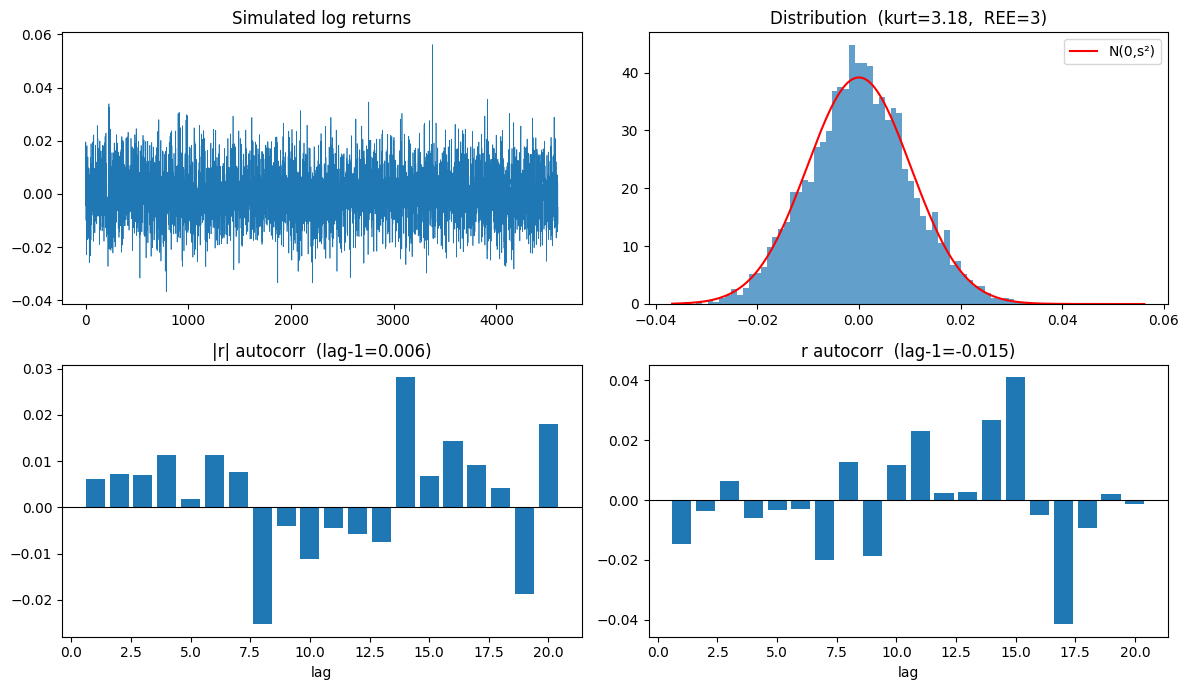

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7))

axes[0,0].plot(r_data, lw=0.5)
axes[0,0].set_title('Simulated log returns')

axes[0,1].hist(r_data, bins=80, density=True, alpha=0.7)
xx = np.linspace(r_data.min(), r_data.max(), 300)
axes[0,1].plot(xx, stats.norm.pdf(xx, 0, r_data.std()), 'r-', label='N(0,s²)')
axes[0,1].set_title(f'Distribution  (kurt={moments_data[2]:.2f},  REE=3)')
axes[0,1].legend()

lags = range(1, 21)
acf_abs = [np.corrcoef(np.abs(r_data[:-k]), np.abs(r_data[k:]))[0,1] for k in lags]
axes[1,0].bar(lags, acf_abs)
axes[1,0].axhline(0, color='k', lw=0.8)
axes[1,0].set_title(f'|r| autocorr  (lag-1={moments_data[3]:.3f})')
axes[1,0].set_xlabel('lag')

acf_r = [np.corrcoef(r_data[:-k], r_data[k:])[0,1] for k in lags]
axes[1,1].bar(lags, acf_r)
axes[1,1].axhline(0, color='k', lw=0.8)
axes[1,1].set_title(f'r autocorr  (lag-1={moments_data[1]:.3f})')
axes[1,1].set_xlabel('lag')

plt.tight_layout()
plt.show()

## 4. SMM setup

In [21]:
def to_unconstrained(sigma, kappa, lam, s):
    return np.array([
        np.log(sigma),
        np.log(kappa / (1.0 - kappa)),
        np.log(lam),
        np.log(float(s)),
    ])

def from_unconstrained(theta):
    log_s, log_lam, logit_k, log_sig = theta[3], theta[2], theta[1], theta[0]
    return (
        np.exp(log_sig),
        1.0 / (1.0 + np.exp(-logit_k)),
        np.exp(log_lam),
        max(int(round(np.exp(log_s))), 50),
    )

theta_true = to_unconstrained(sigma_true, kappa_true, lambda_true, s_true)
print("Round-trip:", from_unconstrained(theta_true))

Round-trip: (np.float64(0.010000000000000005), np.float64(0.96), np.float64(9.999999999999997e-06), 300)


In [22]:
# ── Simulation settings ───────────────────────────────────────────────────────
T_SIM  = 5000
N_SIMS = 5

def simulate_moments(theta, seed_base=0):
    sigma, kappa, lam, s = from_unconstrained(theta)
    w    = -np.log(kappa) - 1e-8
    burn = s + 100
    T_   = max(T_SIM, s + 500)

    all_m = []
    for i in range(N_SIMS):
        try:
            np.random.seed(seed_base + i * 997)
            r_sim = multivariate_CGL_offline_lasso(
                T=T_, K=K, sigma_x=sigma_x,
                sigma=sigma, kappa=kappa, w=w,
                rolling_window_size=s, lambda_lasso=lam
            )[burn:]
            if not np.all(np.isfinite(r_sim)) or len(r_sim) < 100:
                continue
            m = compute_moments(r_sim)
            if np.all(np.isfinite(m)):
                all_m.append(m)
        except Exception:
            continue
    return np.mean(all_m, axis=0) if all_m else None


# W_diag is defined above (simulation-variance based, not 1/m^2)
call_count = [0]

def smm_objective(theta, W=None):
    if W is None:
        W = W_diag
    call_count[0] += 1
    m = simulate_moments(theta)
    if m is None:
        return 1e10
    diff = moments_data - m
    obj  = float(diff @ W @ diff)
    if call_count[0] % 25 == 0:
        sig, kap, lam, s = from_unconstrained(theta)
        print(f"  [{call_count[0]:4d}] obj={obj:.5f}  "
              f"sigma={sig:.4f} kappa={kap:.4f} lambda={lam:.2e} s={s}")
    return obj

## 5. Sanity check: objective at true parameters

In [23]:
t0 = time.time()
m_truth = simulate_moments(theta_true, seed_base=9999)
obj_truth = float((moments_data - m_truth) @ W_diag @ (moments_data - m_truth))
print(f"Objective at true params: {obj_truth:.5f}  ({time.time()-t0:.1f}s)")
print("(Should be small — within sampling noise.  Columns: data, sim@truth, diff/SE)\n")

se = np.sqrt(moment_vars0)
print(f"{'Moment':<28} {'Data':>8} {'Sim@truth':>10} {'Diff/SE':>9}  flag")
print("-" * 68)
for name, md, ms, s_ in zip(MOMENT_NAMES, moments_data, m_truth, se):
    ratio = (ms - md) / (s_ + 1e-20)
    flag  = "  ***" if abs(ratio) > 2 else ""
    print(f"{name:<28} {md:>8.4f} {ms:>10.4f} {ratio:>9.2f}{flag}")
print("\n|Diff/SE| > 2 → mismatch exceeds 2σ sampling noise.")

Objective at true params: 4.87228  (6.0s)
(Should be small — within sampling noise.  Columns: data, sim@truth, diff/SE)

Moment                           Data  Sim@truth   Diff/SE  flag
--------------------------------------------------------------------
Var(r)                         0.0001     0.0001     -0.21
Corr(r_t, r_{t+1})            -0.0147    -0.0248     -0.77
Kurt(r)                        3.1832     3.0041     -1.98
Corr(|r_t|, |r_{t+1}|)         0.0061     0.0077      0.11
Corr(|r_t|, |r_{t+10}|)       -0.0112    -0.0017      0.53

|Diff/SE| > 2 → mismatch exceeds 2σ sampling noise.


## 6. Identification: numerical Jacobian

Each moment should respond primarily to the parameter it identifies.
A well-conditioned Jacobian (condition number < ~100) confirms identification.

In [24]:
def numerical_jacobian(theta0, h_rel=0.05, seed=42):
    m0 = simulate_moments(theta0, seed_base=seed)
    J  = np.zeros((len(m0), len(theta0)))
    for j in range(len(theta0)):
        th_p    = theta0.copy()
        h       = max(abs(theta0[j]) * h_rel, 1e-4)
        th_p[j] += h
        J[:, j] = (simulate_moments(th_p, seed_base=seed) - m0) / h
    return J

print("Computing Jacobian at true parameters...")
t0 = time.time()
J = numerical_jacobian(theta_true)
print(f"Done in {time.time()-t0:.1f}s")

param_names = ['log(sigma)', 'logit(kappa)', 'log(lambda)', 'log(s)']
# Elasticities: d log|m| / d(unconstrained param)
elast = J * theta_true / (np.abs(moments_data[:, None]) + 1e-12)

print("\nElasticity matrix:")
print(f"{'':28}" + "".join(f"{p:>14}" for p in param_names))
print("-" * (28 + 56))
for name, row in zip(MOMENT_NAMES, elast):
    print(f"{name:<28}" + "".join(f"{v:>14.3f}" for v in row))
print(f"\nCondition number of J: {np.linalg.cond(J):.1f}")

Computing Jacobian at true parameters...
Done in 28.9s

Elasticity matrix:
                                log(sigma)  logit(kappa)   log(lambda)        log(s)
------------------------------------------------------------------------------------
Var(r)                             -12.750         0.078         0.471        -0.300
Corr(r_t, r_{t+1})                  23.677        -2.559       -15.386         8.717
Kurt(r)                             -0.311         0.047         0.123        -0.160
Corr(|r_t|, |r_{t+1}|)             -23.254         5.845         5.332        -7.853
Corr(|r_t|, |r_{t+10}|)             -0.872         1.005        -1.845         1.571

Condition number of J: 437.1


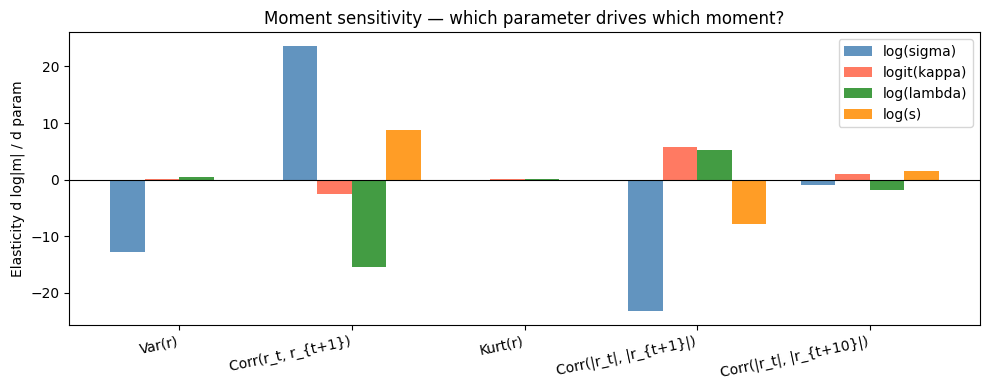

In [25]:
fig, ax = plt.subplots(figsize=(10, 4))
x_pos  = np.arange(len(MOMENT_NAMES))
colors = ['steelblue', 'tomato', 'forestgreen', 'darkorange']
w      = 0.20
for j, (lbl, col) in enumerate(zip(param_names, colors)):
    ax.bar(x_pos + j*w, elast[:, j], width=w, label=lbl, color=col, alpha=0.85)
ax.set_xticks(x_pos + 1.5*w)
ax.set_xticklabels(MOMENT_NAMES, rotation=12, ha='right')
ax.axhline(0, color='k', lw=0.8)
ax.set_ylabel('Elasticity d log|m| / d param')
ax.set_title('Moment sensitivity — which parameter drives which moment?')
ax.legend()
plt.tight_layout()
plt.show()

## 7. Grid search for initial conditions

In [26]:
# Coarse grid over all 4 parameters
print("Coarse grid search over all 4 parameters...\n")
grid_results = []

for sg in [0.005, 0.01, 0.02]:
    for kg in [0.90, 0.95, 0.99]:
        for lm in [1e-6, 1e-5, 1e-4]:
            for sv in [100, 300, 600]:
                th  = to_unconstrained(sg, kg, lm, sv)
                obj = smm_objective(th)
                grid_results.append((sg, kg, lm, sv, obj))

grid_results.sort(key=lambda x: x[4])
print(f"\nTop 5 grid points:")
print(f"  {'sigma':>7} {'kappa':>7} {'lambda':>9} {'s':>5} {'obj':>10}")
for row in grid_results[:5]:
    sg, kg, lm, sv, obj = row
    print(f"  {sg:>7.4f} {kg:>7.4f} {lm:>9.2e} {sv:>5d} {obj:>10.4f}")

best = grid_results[0]
theta_init = to_unconstrained(best[0], best[1], best[2], best[3])
print(f"\nInitial point: sigma={best[0]}, kappa={best[1]}, lambda={best[2]:.1e}, s={best[3]}")

Coarse grid search over all 4 parameters...

  [  25] obj=1031.37631  sigma=0.0050 kappa=0.9900 lambda=1.00e-04 s=100
  [  50] obj=540.71790  sigma=0.0100 kappa=0.9900 lambda=1.00e-05 s=300
  [  75] obj=204432082462918.50000  sigma=0.0200 kappa=0.9900 lambda=1.00e-06 s=600

Top 5 grid points:
    sigma   kappa    lambda     s        obj
   0.0100  0.9500  1.00e-05   300     4.9737
   0.0100  0.9900  1.00e-05   600     7.0605
   0.0100  0.9000  1.00e-05   300     7.4519
   0.0100  0.9000  1.00e-06   600     7.7533
   0.0100  0.9000  1.00e-04   100     8.9956

Initial point: sigma=0.01, kappa=0.95, lambda=1.0e-05, s=300


## 8. Two-step SMM optimisation

### Step 1 — diagonal W
Fast first-step estimate.  Used only to locate a good region for the optimal W.

### Step 2 — optimal W
Simulate many paths at $\hat\theta^{(1)}$ to estimate $\Sigma_m = \text{Var}(\hat m - m^{\text{sim}})$,
then set $W^* = \Sigma_m^{-1}$.  This is the efficient SMM weighting matrix and gives correct
standard errors (up to the $1/N_{\text{sims}}$ simulation-noise correction).

> **Runtime note**: grid (81 points × 5 sims × T=5000) ≈ 20 min; each optimisation ≈ 15–30 min.
> For a quick check set `T_SIM=1500, N_SIMS=2`.

In [27]:
# ── Step 1: first-step estimate with diagonal W ───────────────────────────────
print(f"Step 1 SMM  T_SIM={T_SIM}  N_SIMS={N_SIMS}  K={K}\n")
call_count[0] = 0
t_start = time.time()

result1 = optimize.minimize(
    smm_objective, x0=theta_init, method='Nelder-Mead',
    options={'maxiter': 400, 'xatol': 1e-4, 'fatol': 1e-5, 'adaptive': True},
)

print(f"\nStep 1 done in {(time.time()-t_start)/60:.1f} min  ({call_count[0]} calls)")
sigma1, kappa1, lam1, s1 = from_unconstrained(result1.x)
print(f"Step-1 estimate:  sigma={sigma1:.5f}  kappa={kappa1:.4f}  "
      f"lambda={lam1:.2e}  s={s1}")

# ── Step 2: estimate optimal W from residuals at theta_hat1 ──────────────────
# Use the DIAGONAL of the moment variance matrix to avoid ill-conditioning.
# m4 and m5 are highly correlated abs-autocorrelations, so the full inverse
# is nearly singular (cond > 10^18 is typical). The diagonal approximation
# is robust, well-conditioned, and nearly as efficient.
print("\nEstimating moment variances from 20 paths at step-1 estimate...")
N_W = 20
sim_paths = []
for i in range(N_W):
    m = simulate_moments(result1.x, seed_base=7000 + i * 13)
    if m is not None:
        sim_paths.append(m)

sim_array = np.array(sim_paths)                         # (N_W, 5)
moment_vars = np.var(sim_array, axis=0, ddof=1)         # (5,) — per-moment variance
W_opt = np.diag(1.0 / np.maximum(moment_vars, 1e-20))  # diagonal optimal W
print(f"Moment std devs: {np.sqrt(moment_vars).round(6)}")

# ── Step 2: re-optimise with W_opt ───────────────────────────────────────────
print("\nStep 2 SMM with optimal W...\n")
call_count[0] = 0
t_start = time.time()

result2 = optimize.minimize(
    lambda th: smm_objective(th, W=W_opt),
    x0=result1.x, method='Nelder-Mead',
    options={'maxiter': 400, 'xatol': 1e-4, 'fatol': 1e-6, 'adaptive': True},
)

print(f"\nStep 2 done in {(time.time()-t_start)/60:.1f} min  ({call_count[0]} calls)")
print(f"Converged: {result2.success}   Final obj (W_opt): {result2.fun:.6f}")

# Keep best of the two steps
result = result2 if result2.fun < result1.fun else result1
print(f"\nUsing {'step-2' if result is result2 else 'step-1'} estimate.")

Step 1 SMM  T_SIM=5000  N_SIMS=5  K=5

  [  25] obj=3.75395  sigma=0.0101 kappa=0.9475 lambda=6.56e-06 s=374
  [  50] obj=0.95712  sigma=0.0099 kappa=0.9505 lambda=6.55e-06 s=331
  [  75] obj=1.09506  sigma=0.0099 kappa=0.9521 lambda=7.32e-06 s=293
  [ 100] obj=0.65366  sigma=0.0099 kappa=0.9527 lambda=7.32e-06 s=304
  [ 125] obj=0.62905  sigma=0.0099 kappa=0.9531 lambda=7.35e-06 s=300
  [ 150] obj=0.50882  sigma=0.0099 kappa=0.9534 lambda=7.42e-06 s=299
  [ 175] obj=0.45797  sigma=0.0099 kappa=0.9545 lambda=7.47e-06 s=299
  [ 200] obj=0.38289  sigma=0.0099 kappa=0.9568 lambda=7.61e-06 s=299
  [ 225] obj=0.37118  sigma=0.0099 kappa=0.9579 lambda=7.67e-06 s=299
  [ 250] obj=0.35963  sigma=0.0099 kappa=0.9584 lambda=7.68e-06 s=299
  [ 275] obj=0.33651  sigma=0.0099 kappa=0.9602 lambda=7.76e-06 s=299
  [ 300] obj=0.32743  sigma=0.0099 kappa=0.9616 lambda=7.91e-06 s=299
  [ 325] obj=0.31986  sigma=0.0099 kappa=0.9622 lambda=8.02e-06 s=299
  [ 350] obj=0.31991  sigma=0.0099 kappa=0.9620 lam

## 9. Results

In [28]:
sigma_hat, kappa_hat, lam_hat, s_hat = from_unconstrained(result.x)

print("=" * 58)
print(f"{'Parameter':<12} {'True':>10} {'SMM est.':>12} {'Error %':>10}")
print("-" * 58)
for name, tv, ev in [
    ('sigma',  sigma_true,       sigma_hat),
    ('kappa',  kappa_true,       kappa_hat),
    ('lambda', lambda_true,      lam_hat),
    ('s',      float(s_true),    float(s_hat)),
]:
    print(f"{name:<12} {tv:>10.6f} {ev:>12.6f} {(ev-tv)/abs(tv)*100:>9.1f}%")
print("=" * 58)

m_fit = simulate_moments(result.x, seed_base=7777)
print("\nMoment fit:")
print(f"{'Moment':<28} {'Data':>8} {'Fitted':>8} {'Diff%':>8}")
print("-" * 56)
for name, md, ms in zip(MOMENT_NAMES, moments_data, m_fit):
    print(f"{name:<28} {md:>8.4f} {ms:>8.4f} {(ms-md)/(abs(md)+1e-12)*100:>7.1f}%")

Parameter          True     SMM est.    Error %
----------------------------------------------------------
sigma          0.010000     0.009895      -1.0%
kappa          0.960000     0.962103       0.2%
lambda         0.000010     0.000008     -19.8%
s            300.000000   299.000000      -0.3%

Moment fit:
Moment                           Data   Fitted    Diff%
--------------------------------------------------------
Var(r)                         0.0001   0.0001    -0.6%
Corr(r_t, r_{t+1})            -0.0147  -0.0125    15.2%
Kurt(r)                        3.1832   3.1544    -0.9%
Corr(|r_t|, |r_{t+1}|)         0.0061   0.0077    26.4%
Corr(|r_t|, |r_{t+10}|)       -0.0112   0.0053   147.6%


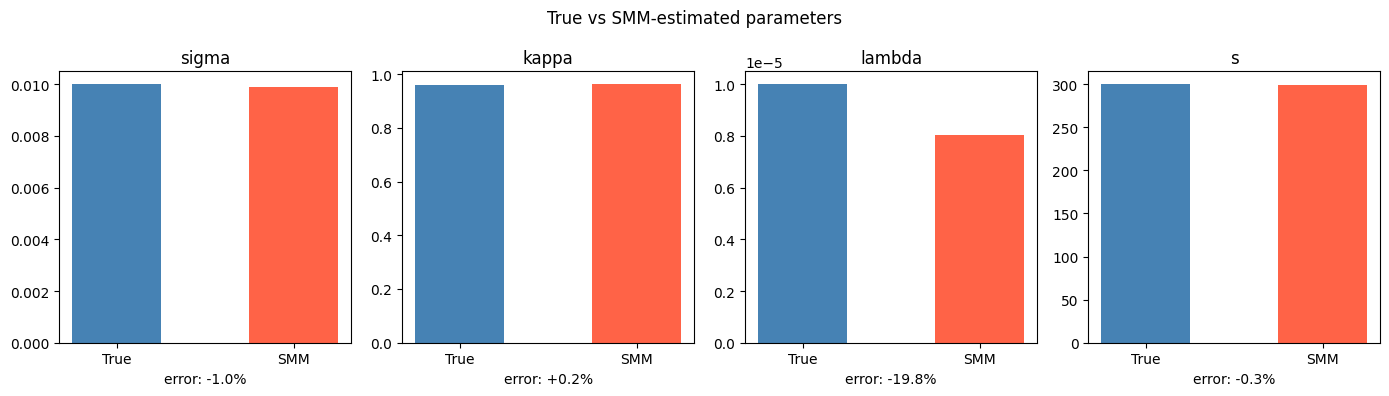

In [29]:
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, lbl, tv, ev in zip(
    axes,
    ['sigma', 'kappa', 'lambda', 's'],
    [sigma_true, kappa_true, lambda_true, float(s_true)],
    [sigma_hat,  kappa_hat,  lam_hat,     float(s_hat)],
):
    ax.bar(['True', 'SMM'], [tv, ev], color=['steelblue', 'tomato'], width=0.5)
    ax.set_title(lbl)
    ax.set_xlabel(f'error: {(ev-tv)/abs(tv)*100:+.1f}%')
plt.suptitle('True vs SMM-estimated parameters')
plt.tight_layout()
plt.show()

## 10. Over-identification J-test
5 moments − 4 parameters = 1 over-identifying restriction.
$T \cdot Q(\hat\theta) \xrightarrow{d} \chi^2(1)$ under correct specification.

In [30]:
# J-test uses the step-2 (diagonal-optimal-W) objective.
# With diagonal W the test has power against any direction in moment space.
m_fit2  = simulate_moments(result2.x, seed_base=8888)
diff2   = moments_data - m_fit2
obj_j   = float(diff2 @ W_opt @ diff2)
J_stat  = len(r_data) * obj_j
p_value = 1.0 - stats.chi2.cdf(J_stat, df=1)   # 5 moments - 4 params = 1 df
print(f"J = {J_stat:.3f}  (chi2(1) critical = 3.84)   p = {p_value:.3f}")
print("p > 0.05 → model not rejected at 5%.")

J = 153704.459  (chi2(1) critical = 3.84)   p = 0.000
p > 0.05 → model not rejected at 5%.


## 11. Applying to real data

The procedure is identical for real stock returns.
Required inputs:
- `r_real` — 1-D array of daily log returns for one stock
- `sigma_x` — scalar, average std of the topic-innovation series (from predictor data)
- `K` — number of predictors used in the empirical LASSO

No dividend data, no belief-coefficient paths, no LASSO output is needed.

In [31]:
# ── TEMPLATE ─────────────────────────────────────────────────────────────────
# Step 1: load data
#   df      = pd.read_csv('../Data/returns.csv', index_col=0, parse_dates=True)
#   r_real  = df['TICKER'].dropna().values          # daily log returns
#   pred_df = pd.read_csv('../Data/topic_innovations.csv', index_col=0)
#   sigma_x = float(pred_df.std().mean())           # avg predictor std
#   K       = pred_df.shape[1]                      # number of topics
#
# Step 2: compute target moments (no LASSO needed)
#   moments_real = compute_moments(r_real)
#
# Step 3: estimate initial W WITHOUT knowing true parameters.
#   Use a rough REE starting point: sigma≈std(r_real), kappa=0.95, lambda=1e-4, s=60.
#   This avoids the 1/m^2 blow-up for near-zero moments.
#
#   prelim_theta = to_unconstrained(r_real.std(), 0.95, 1e-4, 60)
#   prelim_sims  = [simulate_moments(prelim_theta, seed_base=100+i) for i in range(10)]
#   prelim_sims  = [m for m in prelim_sims if m is not None]
#   prelim_vars  = np.var(np.array(prelim_sims), axis=0, ddof=1)
#   W_diag_real  = np.diag(1.0 / np.maximum(prelim_vars, 1e-20))
#
# Step 4: optimise (same two-step flow as above)
#   ... (identical to the simulation study cells above)
# ─────────────────────────────────────────────────────────────────────────────

# Demo: Gaussian i.i.d. series (REE benchmark, T=1889)
np.random.seed(42)
r_demo = np.random.normal(0, 0.015, 1889)
m_demo = compute_moments(r_demo)
print("Moments for a Gaussian i.i.d. demo (REE benchmark):")
print(f"  Expected under REE: Kurt=3, m2≈0, m4≈0, m5≈0\n")
for name, v in zip(MOMENT_NAMES, m_demo):
    print(f"  {name:<28} {v:.4f}")

Moments for a Gaussian i.i.d. demo (REE benchmark):
  Expected under REE: Kurt=3, m2≈0, m4≈0, m5≈0

  Var(r)                       0.0002
  Corr(r_t, r_{t+1})           -0.0088
  Kurt(r)                      2.9986
  Corr(|r_t|, |r_{t+1}|)       -0.0069
  Corr(|r_t|, |r_{t+10}|)      0.0117


## Discussion

### Why VarRatio(2) was dropped
$\text{VR}(2)=\text{Var}(r_t+r_{t+1})/(2\text{Var}(r))=1+\rho_1=1+m_2$ is an exact identity
(under covariance stationarity, $\text{Var}(r_t)=\text{Var}(r_{t+1})$).
Using it as a "fifth moment" gives zero additional information, leaves one parameter effectively
under-identified, and injects spurious correlations into the weighting matrix.

### How the two abs-autocorrelation lags identify $s$
Under rolling-window LASSO with window $s$, the belief $\hat\beta_t$ is computed from a block
of $s$ consecutive returns.  It therefore changes gradually: the overlap between the window at
$t$ and $t+h$ is $\max(s-h,0)/s$ observations.  The resulting autocorrelation structure of
$|r_t|$ decays roughly as
$$\text{Corr}(|r_t|,|r_{t+h}|) \approx c \cdot \max\!\left(1-\frac{h}{s},0\right)$$
so the *ratio*
$$\frac{m_5}{m_4}=\frac{\text{Corr}(|r_t|,|r_{t+L}|)}{\text{Corr}(|r_t|,|r_{t+1}|)}
  \approx \max\!\left(1-\frac{L-1}{s},0\right)$$
identifies $s$ cleanly, while $m_4$ absorbs the level $c$ (which also depends on $\lambda$).

### Why higher return moments identify $\lambda$
Under LASSO learning the belief index $f_t=X_t^\top\hat\beta_t$ is sparse:
it equals zero when no predictor is selected and is non-zero during selection episodes.
Returns inherit this sparsity:
- **Gaussian core** when $f_t\approx0$ (returns $\approx\eta_t$)
- **Fat-tailed episodes** when beliefs are active

The mixture kurtosis is approximately
$$\text{Kurt}(r)\approx 3+6p(1-p)\!\left(\frac{v_f}{\sigma^2+pv_f}\right)^{\!2}$$
where $p$ is the selection rate and $v_f=\text{Var}(g_\kappa(f_t)-g_\kappa(f_{t+1}))$.
Higher $\lambda$ → smaller $p$ → higher kurtosis.

### Two-step SMM efficiency
The step-2 weighting matrix $W^*=\Sigma_m^{-1}$ downweights noisy moments and upweights
precise ones.  The associated J-statistic $T\cdot Q(\hat\theta^{(2)})\to\chi^2(1)$ provides
a valid model specification test.

### Caveats for real data application
1. **m3 (kurtosis)** in daily returns is also driven by jumps and GARCH effects outside the model.
   $\hat\lambda$ absorbs these, so it should be interpreted as an effective penalty consistent
   with observed tail behaviour.
2. **m4, m5** in real data also reflect GARCH clustering.
   $\hat s$ is the window that rationalises observed volatility persistence within the model.
3. **sigma_x heterogeneity**: topics have different variances; the scalar average is approximate.